In [1]:
import dgl.nn as dglnn
import dgl
from dgl import from_networkx
import torch.nn as nn
import torch as th
import torch.nn.functional as F
import dgl.function as fn
import networkx as nx
import pandas as pd
import socket
import struct
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import category_encoders as ce
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
data = pd.read_csv('NF-ToN-IoT-v2-0.03.csv')
data.drop(columns=['Label'],inplace = True)
data.rename(columns={"Attack": "label"},inplace = True)
le = LabelEncoder()
le.fit_transform(data.label.values)
# data['label'] = le.transform(data['label'])
print(le.classes_)

['Benign' 'backdoor' 'ddos' 'dos' 'injection' 'mitm' 'password'
 'ransomware' 'scanning' 'xss']


In [2]:
data = pd.read_csv('NF-ToN-IoT-v2-0.03.csv')
data['IPV4_SRC_ADDR'] = data.IPV4_SRC_ADDR.apply(lambda x: socket.inet_ntoa(struct.pack('>I', random.randint(0xac100001, 0xac1f0001))))
data['IPV4_SRC_ADDR'] = data.IPV4_SRC_ADDR.apply(str)
data['L4_SRC_PORT'] = data.L4_SRC_PORT.apply(str)
data['IPV4_DST_ADDR'] = data.IPV4_DST_ADDR.apply(str)
data['L4_DST_PORT'] = data.L4_DST_PORT.apply(str)
data['IPV4_SRC_ADDR'] = data['IPV4_SRC_ADDR'] + ':' + data['L4_SRC_PORT']
data['IPV4_DST_ADDR'] = data['IPV4_DST_ADDR'] + ':' + data['L4_DST_PORT']
data.drop(columns=['L4_SRC_PORT','L4_DST_PORT'],inplace=True)
data.drop(columns=['Label'],inplace = True)
data.rename(columns={"Attack": "label"},inplace = True)
le = LabelEncoder()
le.fit_transform(data.label.values)
data['label'] = le.transform(data['label'])
label = data.label
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(data, label, test_size=0.3, random_state=123,stratify= label)
cols_to_norm = list(set(list(X_train.iloc[:, 2:].columns ))  - set(list(['label'])) )

X_train[cols_to_norm] = scaler.fit_transform(X_train[cols_to_norm])
X_train['h'] = X_train[ cols_to_norm ].values.tolist()
G = nx.from_pandas_edgelist(X_train, "IPV4_SRC_ADDR", "IPV4_DST_ADDR", ['h','label'],create_using=nx.MultiGraph())
G = G.to_directed()
G = from_networkx(G,edge_attrs=['h','label'] )
G.ndata['h'] = th.ones(G.num_nodes(), G.edata['h'].shape[1])

X_test[cols_to_norm] = scaler.fit_transform(X_test[cols_to_norm])
X_test['h'] = X_test[ cols_to_norm ].values.tolist()
G_test = nx.from_pandas_edgelist(X_test, "IPV4_SRC_ADDR", "IPV4_DST_ADDR", ['h','label'],create_using=nx.MultiGraph())
G_test = G_test.to_directed()
G_test = from_networkx(G_test,edge_attrs=['h','label'] )
G_test.ndata['h'] = th.ones(G_test.num_nodes(), G_test.edata['h'].shape[1])

In [4]:
dgl.save_graphs('train_m.bin', [G])

In [5]:
device = th.device('cuda' if th.cuda.is_available() else 'cpu')

In [2]:
device = th.device('cuda' if th.cuda.is_available() else 'cpu')
graphs, _ = dgl.load_graphs('train_m.bin')
G = graphs[0]

In [3]:
G = G.to(device)
node_features = G.ndata['h']
edge_features = G.edata['h']
edge_label = G.edata['label']


In [4]:
print(device)

cuda


In [5]:
print(node_features.shape[0])
print(edge_features.shape[0])

434536
711502


In [6]:
def compute_accuracy(pred, labels):
    return (pred.argmax(1) == labels).float().mean().item()

class SAGELayer(nn.Module):
    def __init__(self, ndim_in, edims, ndim_out ):
        super(SAGELayer, self).__init__()
        ### force to outut fix dimensions
        self.W_msg = nn.Linear(ndim_in + edims, ndim_out)
        ### apply weight
        self.W_apply = nn.Linear(ndim_in + ndim_out, ndim_out)
        

    def message_func(self, edges):
        return {'m': self.W_msg(th.cat([edges.data['h'], edges.dst['h']], 1))}

    def forward(self, g_dgl, nfeats, efeats):
        with g_dgl.local_scope():
            g = g_dgl
            g.ndata['h'] = nfeats
            g.edata['h'] = efeats
            # Eq4
            g.update_all(self.message_func, fn.mean('m', 'h_neigh'))
            # Eq5          
            g.ndata['h'] = F.relu(self.W_apply(th.cat([g.ndata['h'], g.ndata['h_neigh']], 1)))
            return g.ndata['h']

class MLPPredictor(nn.Module):
    def __init__(self, in_features, edim, out_classes):
        super().__init__()
        self.W = nn.Linear(in_features * 2 + edim, out_classes)

    def apply_edges(self, edges):
        h_u = edges.src['h']
        h_v = edges.dst['h']
        h_e = edges.data['h']
        score = self.W(th.cat([h_u, h_e, h_v], 1))
        return {'score': score}

    def forward(self, graph, h, efeats):
        with graph.local_scope():
            graph.ndata['h'] = h
            graph.edata['h'] = efeats
            graph.apply_edges(self.apply_edges)
            return graph.edata['score']

class Model(nn.Module):
    def __init__(self,  ndim_in, ndim_out, edim):
        super().__init__()
        self.atten = nn.Parameter(th.randn(1, edim))
        self.cov1 = SAGELayer(ndim_in, edim, ndim_out)
        self.cov2 = SAGELayer(ndim_out, edim, ndim_out)
        self.pred = MLPPredictor(ndim_out, edim, 10)
        self.dropout = nn.Dropout(p=0.2)
        
    def forward(self, g, nfeats, efeats):
        efeats = efeats * self.atten
        nfeats = F.relu(self.cov1(g, nfeats, efeats))
        nfeats = self.dropout(nfeats)
        nfeats = F.relu(self.cov2(g, nfeats, efeats))
        nfeats = self.dropout(nfeats)
        return self.pred(g, nfeats, efeats)


In [7]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                 classes=np.unique(G.edata['label'].cpu().numpy()),
                                                 y=G.edata['label'].cpu().numpy())

In [8]:
class_weights = th.FloatTensor(class_weights).cuda()
criterion = nn.CrossEntropyLoss(weight = class_weights)

In [7]:

model = Model( G.ndata['h'].shape[1], 128, G.edata['h'].shape[1]).to(device)
opt = th.optim.Adam(model.parameters())

In [10]:
for epoch in range(300):
    pred = model( G, node_features, edge_features)
    loss = criterion(pred ,edge_label)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if (epoch+1) % 100 == 0:
      print('Training acc:', compute_accuracy(pred, edge_label))

Training acc: 0.6147066354751587
Training acc: 0.848266065120697
Training acc: 0.8602786660194397


In [16]:
for epoch in range(50):
    pred = model( G, node_features, edge_features)
    loss = criterion(pred ,edge_label)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if (epoch+1) % 100 == 0:
      print('Training acc:', compute_accuracy(pred, edge_label))

In [21]:
for epoch in range(50):
    pred = model( G, node_features, edge_features)
    loss = criterion(pred ,edge_label)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if (epoch+1) % 50 == 0:
      print('Training acc:', compute_accuracy(pred, edge_label))

Training acc: 0.8749110698699951


In [28]:
for epoch in range(50):
    pred = model( G, node_features, edge_features)
    loss = criterion(pred ,edge_label)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if (epoch+1) % 50 == 0:
      print('Training acc:', compute_accuracy(pred, edge_label))

Training acc: 0.8694226741790771


In [32]:
for epoch in range(50):
    pred = model( G, node_features, edge_features)
    loss = criterion(pred ,edge_label)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if (epoch+1) % 50 == 0:
      print('Training acc:', compute_accuracy(pred, edge_label))

Training acc: 0.8801676034927368


In [36]:
for epoch in range(50):
    pred = model( G, node_features, edge_features)
    loss = criterion(pred ,edge_label)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if (epoch+1) % 50 == 0:
      print('Training acc:', compute_accuracy(pred, edge_label))

Training acc: 0.8936418890953064


In [38]:
th.save(model.state_dict(),'A-SAGE-R_m-w-128-550.pth')

In [8]:
model.load_state_dict(th.load('A-SAGE-R_m-w-128-550.pth'))

<All keys matched successfully>

In [9]:
graphs, _ = dgl.load_graphs('test_m.bin')
G_test = graphs[0]

In [10]:
G_test = G_test.to(device)
node_features_test = G_test.ndata['h']
edge_features_test = G_test.edata['h']
edge_label_test = G_test.edata['label']


In [11]:
print(node_features_test.shape[0])
print(edge_features_test.shape[0])

193975
304930


In [12]:

out = model( G_test, node_features_test, edge_features_test)
pred1 = F.softmax(out, dim=1)
_, pred = pred1.max(dim=1)
print(classification_report(edge_label_test.cpu().numpy(), pred.cpu().numpy(), digits=4))

              precision    recall  f1-score   support

           0     0.9787    0.9292    0.9533    109790
           1     0.8412    1.0000    0.9138       302
           2     0.9564    0.9255    0.9407     36472
           3     0.4906    0.9421    0.6452     12828
           4     0.5987    0.7725    0.6746     12320
           5     0.0297    0.3286    0.0545       140
           6     0.9058    0.7501    0.8207     20760
           7     0.0328    0.9677    0.0634        62
           8     0.9357    0.9632    0.9493     68066
           9     0.9063    0.6948    0.7866     44190

    accuracy                         0.8842    304930
   macro avg     0.6676    0.8274    0.6802    304930
weighted avg     0.9143    0.8842    0.8929    304930



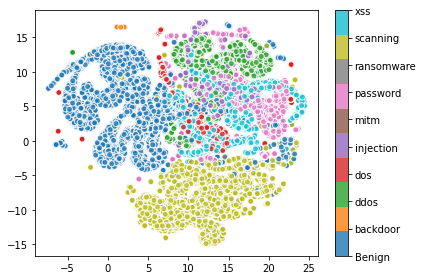

In [13]:
import umap

label_mapping = {
    0: 'Benign',
    1: 'backdoor',
    2: 'ddos',
    3: 'dos',
    4: 'injection',
    5: 'mitm',
    6: 'password',
    7: 'ransomware',
    8: 'scanning',
    9: 'xss'
}

umap_model = umap.UMAP(n_components=2,n_jobs=-1)
node_embeddings_2d = umap_model.fit_transform(pred1.detach().cpu().numpy())

scatter = plt.scatter(node_embeddings_2d[:, 0], node_embeddings_2d[:, 1], 
                      c=edge_label_test.cpu().numpy(), cmap='tab10', marker='o',
                      s=35,                # 增大点的大小
                      edgecolors='white',  # 设置边界颜色为白色
                      linewidths=1.1,      # 设置边界宽度
                      alpha=0.8)           # 设置透明度
# for i in np.unique(edge_label_test.cpu().numpy()):
#     plt.scatter([], [], c=[scatter.cmap(i/10)], label=label_mapping[i])
# plt.legend(frameon=False)

cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])  # 设置刻度的位置，这里假设标签是 0, 1, 2, 3, 4
cbar.set_ticklabels([label_mapping[i] for i in range(10)])  # 使用标签映射来替换刻度标签

plt.tight_layout()
plt.savefig('nf-ton-v2.jpg',dpi=300)
plt.show()


In [37]:
#w-128-550
out = model( G_test, node_features_test, edge_features_test)
out = F.softmax(out, dim=1)
_, pred = out.max(dim=1)
print(classification_report(edge_label_test.cpu().numpy(), pred.cpu().numpy(), digits=4))

              precision    recall  f1-score   support

           0     0.9776    0.9321    0.9543    109790
           1     0.7865    1.0000    0.8805       302
           2     0.9594    0.9217    0.9402     36472
           3     0.5036    0.9213    0.6512     12828
           4     0.5697    0.7937    0.6633     12320
           5     0.0270    0.3286    0.0498       140
           6     0.9186    0.7184    0.8062     20760
           7     0.0314    0.9677    0.0608        62
           8     0.9386    0.9634    0.9509     68066
           9     0.9080    0.7084    0.7958     44190

    accuracy                         0.8846    304930
   macro avg     0.6620    0.8255    0.6753    304930
weighted avg     0.9154    0.8846    0.8936    304930

